In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [86]:
data = pd.read_csv(r"Datasets\placement.csv")
data.head()


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [88]:
data.describe()

,Unnamed: 0,cgpa,iq,placement
count,100.000000,100.000000,100.000000,100.000000
mean,49.500000,5.991000,123.580000,0.500000
std,29.011492,1.143634,39.944198,0.502519
min,0.000000,3.300000,37.000000,0.000000
25%,24.750000,5.075000,101.500000,0.000000
50%,49.500000,6.000000,127.500000,0.500000
75%,74.250000,6.900000,149.000000,1.000000
max,99.000000,8.500000,233.000000,1.000000


In [89]:
data.sample(5)

,Unnamed: 0,cgpa,iq,placement
44,44,7.5,61.0,1
3,3,7.4,132.0,1
6,6,5.7,143.0,0
85,85,5.8,166.0,1
79,79,6.5,90.0,1


In [90]:
data1 =  data.iloc[:,1:]
print(data1)

    cgpa     iq  placement
0    6.8  123.0          1
1    5.9  106.0          0
2    5.3  121.0          0
3    7.4  132.0          1
4    5.8  142.0          0
..   ...    ...        ...
95   4.3  200.0          0
96   4.4   42.0          0
97   6.7  182.0          1
98   6.3  103.0          1
99   6.2  113.0          1

[100 rows x 3 columns]


In [91]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(data1.drop('placement', axis=1),
                                                    data1['placement'],
                                                    test_size=0.3,random_state=0)

In [92]:
X_train

,cgpa,iq
60,6.9,139.0
80,4.9,196.0
90,7.3,86.0
68,4.0,75.0
51,4.8,141.0
...,...,...
96,4.4,42.0
67,5.0,118.0
64,7.0,64.0
47,5.2,161.0


In [93]:
X_test.head()

,cgpa,iq
26,7.0,199.0
86,5.1,128.0
2,5.3,121.0
55,7.8,114.0
75,4.8,169.0


In [94]:
X_train.shape, X_test.shape

((70, 2), (30, 2))

In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [96]:
scaler.mean_

array([  5.98571429, 121.68571429])

In [97]:
X_train

,cgpa,iq
60,6.9,139.0
80,4.9,196.0
90,7.3,86.0
68,4.0,75.0
51,4.8,141.0
...,...,...
96,4.4,42.0
67,5.0,118.0
64,7.0,64.0
47,5.2,161.0


In [98]:
X_train_scaled

array([[ 0.76561378,  0.44343764],
       [-0.90916636,  1.90326946],
       [ 1.10056981, -0.91394985],
       [-1.66281743, -1.19567178],
       [-0.99290537,  0.49465981],
       [ 0.01196272,  0.05927137],
       [-1.66281743, -0.55539466],
       [ 0.09570172, -1.45178263],
       [ 0.26317974,  0.16171571],
       [ 0.59813576,  0.82760391],
       [-0.07177629, -0.40172816],
       [ 1.10056981,  0.39221547],
       [ 1.35178683, -0.8371166 ],
       [-0.49047133, -0.19683948],
       [-0.1555153 ,  0.52027089],
       [-0.74168835,  1.39104777],
       [-2.24899047,  1.57032536],
       [-0.90916636,  0.31538221],
       [ 0.43065775,  0.98127042],
       [ 0.93309179, -1.88717107],
       [ 1.26804782,  0.93004825],
       [-0.99290537, -0.24806165],
       [ 0.68187477,  0.03366028],
       [-0.99290537,  1.05810367],
       [-0.65794934, -0.81150551],
       [-2.08151246,  2.8508796 ],
       [ 0.76561378,  0.41782655],
       [ 0.68187477, -0.81150551],
       [-1.07664438,

In [99]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [100]:
np.round(X_train_scaled.describe(), 1)

,cgpa,iq
count,70.0,70.0
mean,-0.0,0.0
std,1.0,1.0
min,-2.2,-2.0
25%,-0.8,-0.8
50%,0.0,0.1
75%,0.8,0.7
max,2.1,2.9


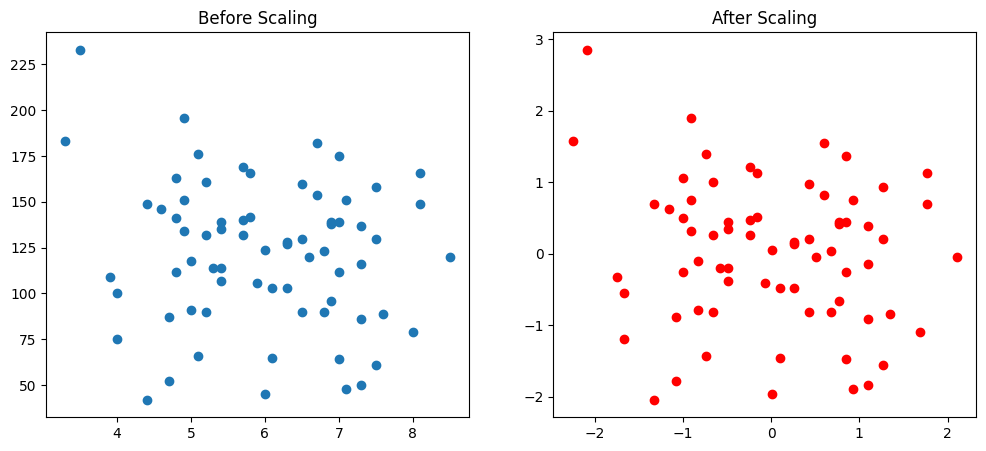

In [102]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['cgpa'], X_train['iq'])
ax1.set_title("Before Scaling")

ax2.scatter(X_train_scaled['cgpa'], X_train_scaled['iq'],color='red')
ax2.set_title("After Scaling")
plt.show()

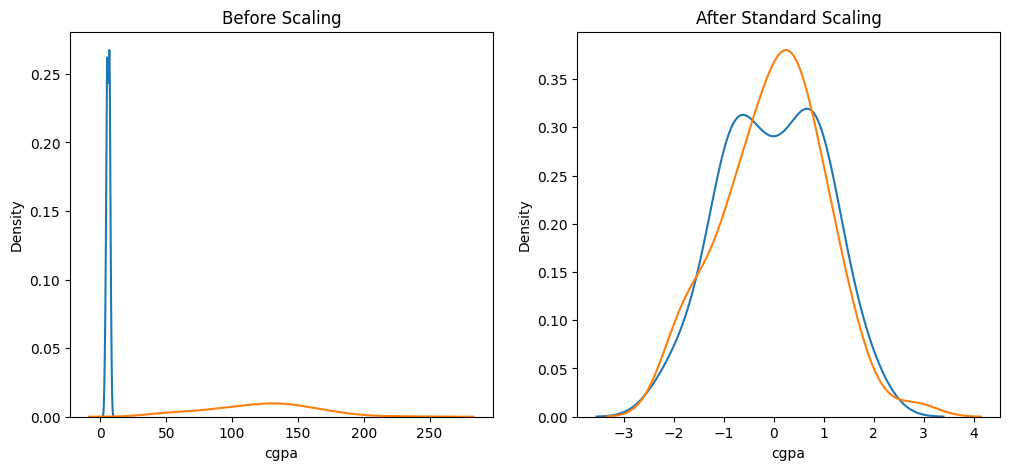

In [103]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['cgpa'], ax=ax1)
sns.kdeplot(X_train['iq'], ax=ax1)

ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['cgpa'], ax=ax2)
sns.kdeplot(X_train_scaled['iq'], ax=ax2)
plt.show()

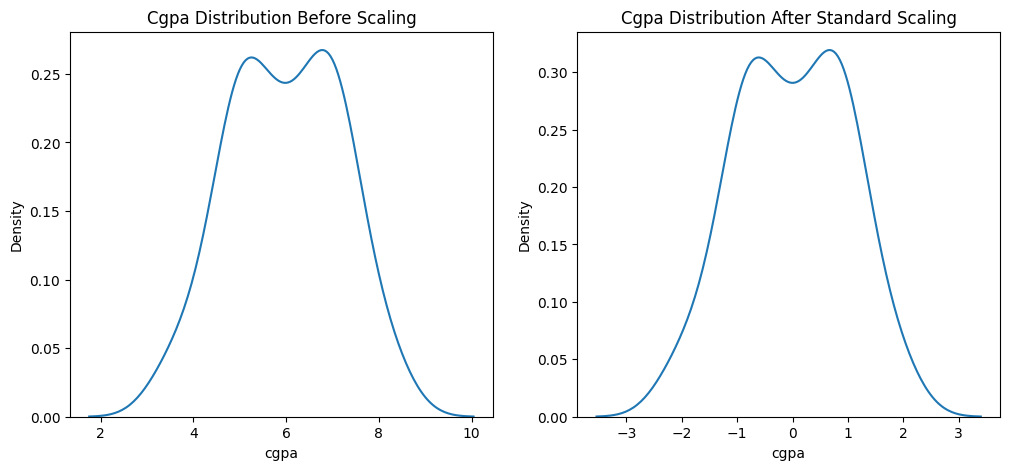

In [105]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title('Cgpa Distribution Before Scaling')
sns.kdeplot(X_train['cgpa'], ax=ax1)

ax2.set_title('Cgpa Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['cgpa'], ax=ax2)
plt.show()

In [106]:
from sklearn.linear_model import LogisticRegression

In [108]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [109]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [110]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [111]:
from sklearn.metrics import accuracy_score

In [112]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.8333333333333334
Scaled 0.8666666666666667
